In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful ✅")

All imports successful ✅


In [2]:
ratings = pd.read_csv("../../Data/raw/ratings.csv")
movies  = pd.read_csv("../../Data/raw/movies.csv")
tags    = pd.read_csv("../../Data/raw/tags.csv")

print(f"Ratings : {ratings.shape}")
print(f"Movies  : {movies.shape}")
print(f"Tags    : {tags.shape}")

Ratings : (100836, 4)
Movies  : (9742, 3)
Tags    : (3683, 4)


In [3]:
print("=== RATINGS INFO ===")
print(f"Unique users  : {ratings['userId'].nunique()}")
print(f"Unique movies : {ratings['movieId'].nunique()}")
print(f"Rating range  : {ratings['rating'].min()} – {ratings['rating'].max()}")
print()
ratings.head()

=== RATINGS INFO ===
Unique users  : 610
Unique movies : 9724
Rating range  : 0.5 – 5.0



,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


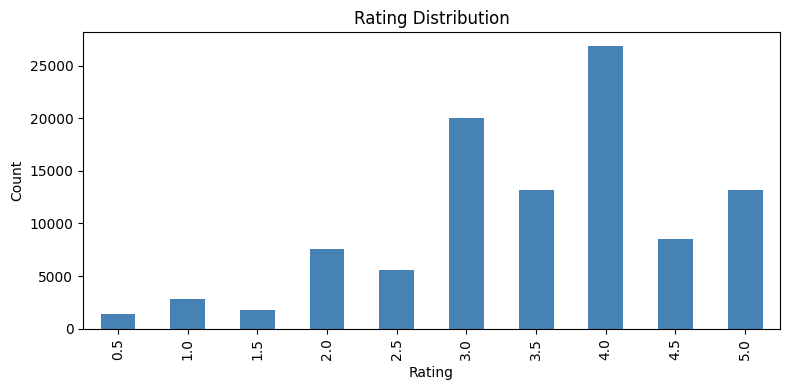

In [4]:
plt.figure(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
data = ratings.merge(movies, on='movieId')

top_movies = (data.groupby('title')['rating']
                  .agg(['count', 'mean'])
                  .sort_values('count', ascending=False)
                  .head(10))

print("Most rated movies:")
print(top_movies)

Most rated movies:
                                           count      mean
title                                                     
Forrest Gump (1994)                          329  4.164134
Shawshank Redemption, The (1994)             317  4.429022
Pulp Fiction (1994)                          307  4.197068
Silence of the Lambs, The (1991)             279  4.161290
Matrix, The (1999)                           278  4.192446
Star Wars: Episode IV - A New Hope (1977)    251  4.231076
Jurassic Park (1993)                         238  3.750000
Braveheart (1995)                            237  4.031646
Terminator 2: Judgment Day (1991)            224  3.970982
Schindler's List (1993)                      220  4.225000


In [6]:
user_item_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

sparsity = user_item_matrix.isna().sum().sum() / user_item_matrix.size * 100

print(f"Matrix shape : {user_item_matrix.shape}")
print(f"Sparsity     : {sparsity:.1f}% empty")
user_item_matrix.iloc[:5, :8]

Matrix shape : (610, 9724)
Sparsity     : 98.3% empty


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
